In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("CouponAcceptance.csv")
da=df.copy()

**Feature Engineering**

In [2]:
df.isna().sum()/len(df)*100

,0
destination,0.000000
passanger,0.000000
weather,0.015883
temperature,0.015883
coupon,0.015883
expiration,0.015883
gender,0.015883
age,0.015883
maritalStatus,0.015883
has_children,0.015883


In [3]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Accept(Y/N?)'],
      dtype='object')

In [4]:
df=df.drop(columns="car")

In [5]:
df.dropna(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6013 entries, 22 to 6294
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   destination           6013 non-null   object 
 1   passanger             6013 non-null   object 
 2   weather               6013 non-null   object 
 3   temperature           6013 non-null   float64
 4   coupon                6013 non-null   object 
 5   expiration            6013 non-null   object 
 6   gender                6013 non-null   object 
 7   age                   6013 non-null   object 
 8   maritalStatus         6013 non-null   object 
 9   has_children          6013 non-null   float64
 10  education             6013 non-null   object 
 11  occupation            6013 non-null   object 
 12  income                6013 non-null   object 
 13  Bar                   6013 non-null   object 
 14  CoffeeHouse           6013 non-null   object 
 15  CarryAway             601

In [7]:
for i in df.columns:
  print(df[i].value_counts())
  print("----------------------------------------------------")

destination
No Urgent Place    3161
Work               1613
Home               1239
Name: count, dtype: int64
----------------------------------------------------
passanger
Alone        3241
Friend(s)    1816
Kid(s)        484
Partner       472
Name: count, dtype: int64
----------------------------------------------------
weather
Sunny    6013
Name: count, dtype: int64
----------------------------------------------------
temperature
80.0    4039
55.0    1974
Name: count, dtype: int64
----------------------------------------------------
coupon
Coffee House             2434
Restaurant(<20)          1332
Carry out & Take away     983
Bar                       757
Restaurant(20-50)         507
Name: count, dtype: int64
----------------------------------------------------
expiration
1d    3066
2h    2947
Name: count, dtype: int64
----------------------------------------------------
gender
Female    3207
Male      2806
Name: count, dtype: int64
-----------------------------------------------

In [8]:
df.rename(columns={"Accept(Y/N?)":"Accept"},inplace=True)

In [9]:
df["maritalStatus"].value_counts()

,count
maritalStatus,
Single,2400
Married partner,2365
Unmarried partner,986
Divorced,218
Widowed,44


In [10]:
df["maritalStatus"]=df["maritalStatus"].replace({"Unmarried partner":"Single","Divorced":"Single","Widowed":"Single"})

In [11]:
lst=[]
for i in df.select_dtypes("O"):
  lst.append(i)

In [12]:
lst

['destination',
 'passanger',
 'weather',
 'coupon',
 'expiration',
 'gender',
 'age',
 'maritalStatus',
 'education',
 'occupation',
 'income',
 'Bar',
 'CoffeeHouse',
 'CarryAway',
 'RestaurantLessThan20',
 'Restaurant20To50']

In [13]:
from sklearn.preprocessing import LabelEncoder
for i in lst:
  df[i]=LabelEncoder().fit_transform(df[i])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6013 entries, 22 to 6294
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   destination           6013 non-null   int64  
 1   passanger             6013 non-null   int64  
 2   weather               6013 non-null   int64  
 3   temperature           6013 non-null   float64
 4   coupon                6013 non-null   int64  
 5   expiration            6013 non-null   int64  
 6   gender                6013 non-null   int64  
 7   age                   6013 non-null   int64  
 8   maritalStatus         6013 non-null   int64  
 9   has_children          6013 non-null   float64
 10  education             6013 non-null   int64  
 11  occupation            6013 non-null   int64  
 12  income                6013 non-null   int64  
 13  Bar                   6013 non-null   int64  
 14  CoffeeHouse           6013 non-null   int64  
 15  CarryAway             601

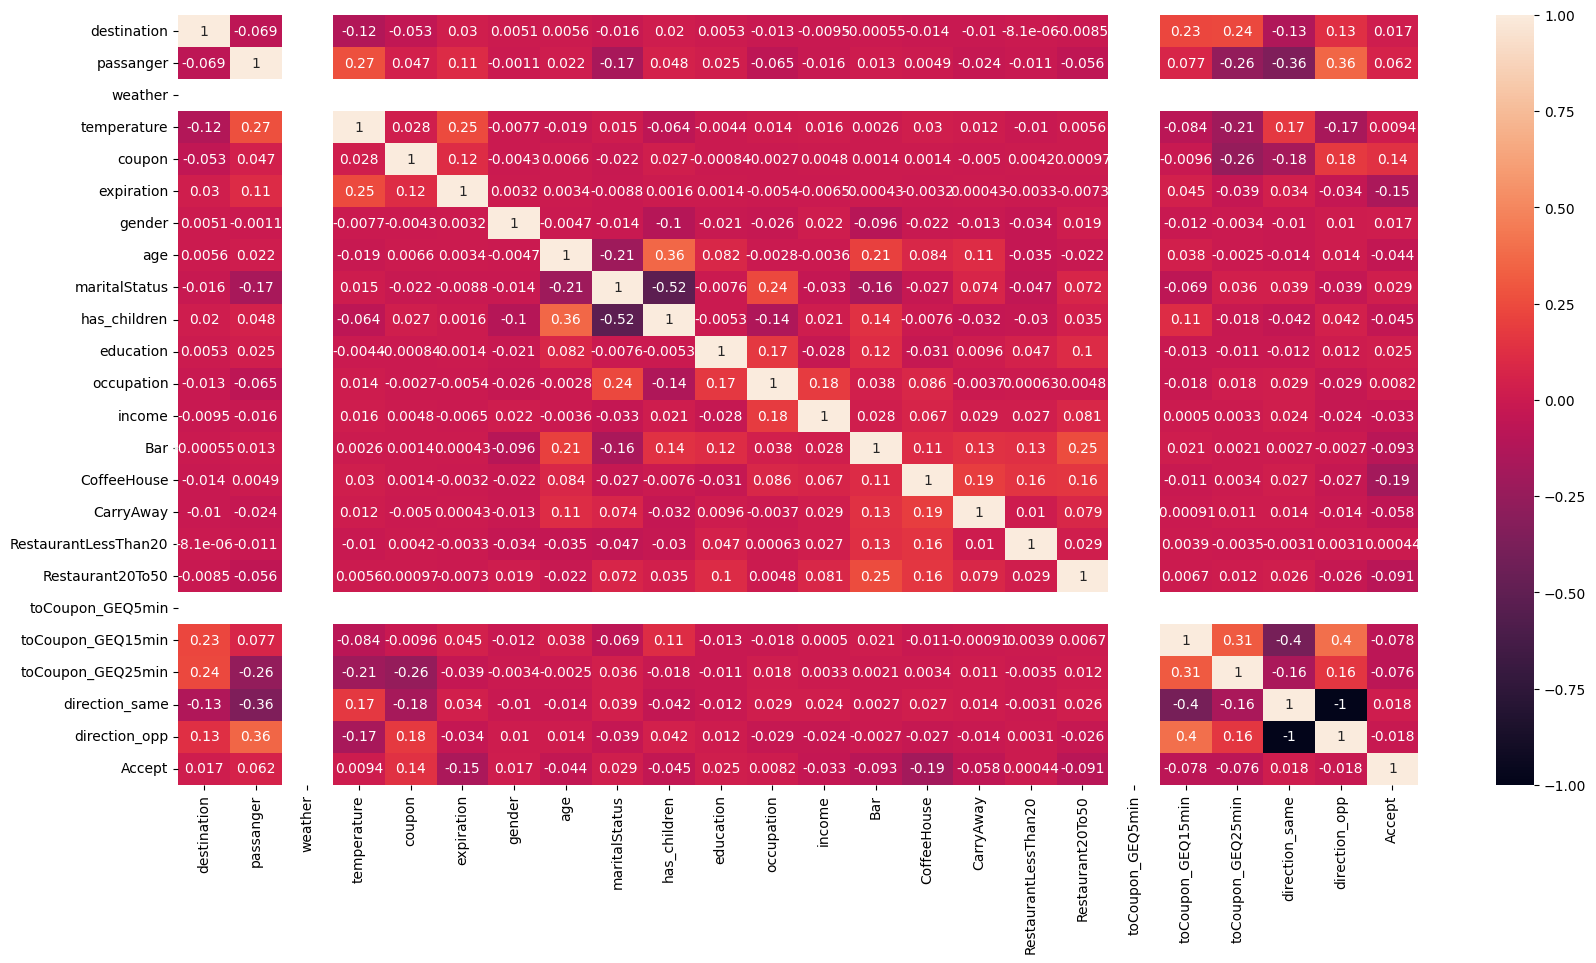

In [15]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [16]:
df=df.drop(columns=["toCoupon_GEQ5min","direction_opp","weather"])

**Exploratory Data analysis**

In [17]:
da=da.drop(columns=["car","toCoupon_GEQ5min","direction_opp"])

In [18]:
da.dropna(inplace=True)

In [19]:
da.rename(columns={"Accept(Y/N?)":"Accept"},inplace=True)

In [20]:
da["maritalStatus"]=da["maritalStatus"].replace({"Unmarried partner":"Single","Divorced":"Single","Widowed":"Single"})

In [21]:
da.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'direction_same', 'Accept'],
      dtype='object')

<Axes: xlabel='gender'>

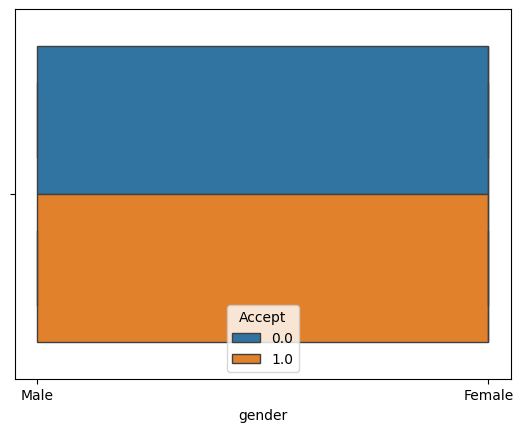

In [22]:
sns.boxplot(x=da["gender"],hue=da["Accept"])

In [23]:
da["Accept"].value_counts()

,count
Accept,
1.0,3494
0.0,2519


In [24]:
df["gender"].value_counts()

,count
gender,
0,3207
1,2806


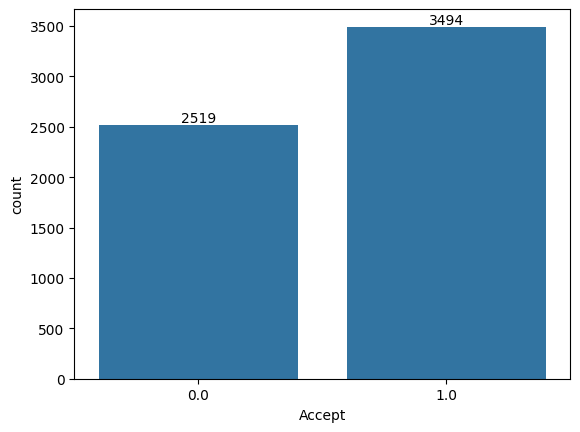

In [25]:
ax=sns.countplot(x="Accept",data=da)
for container in ax.containers:
  ax.bar_label(container)

In [26]:
da.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'direction_same', 'Accept'],
      dtype='object')

In [27]:
def UserCountPlot(col):
  ax=sns.countplot(x=col,hue=da["Accept"])
  for container in ax.containers:
    ax.bar_label(container)


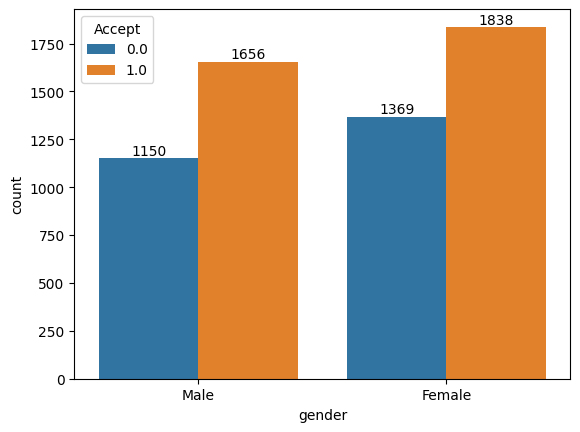

In [28]:
UserCountPlot(da["gender"])

In [29]:
grp1=da.groupby("Accept").agg(TotalRecords=("Accept",np.size),AvgIncome=("income",np.size))
grp1

,TotalRecords,AvgIncome
Accept,,
0.0,2519,2519
1.0,3494,3494


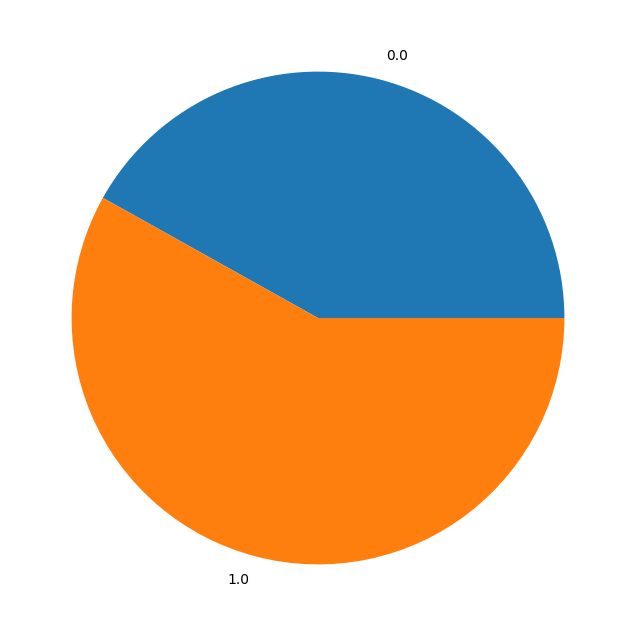

In [31]:
plt.figure(figsize=(10,8))
plt.pie(x=grp1.TotalRecords.values,labels=grp1.index.values)
plt.show()

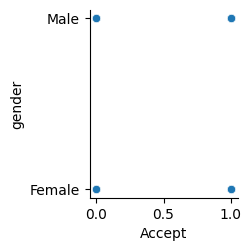

In [34]:
sns.pairplot(x_vars="Accept",y_vars="gender",data=da)

In [36]:
da.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'direction_same', 'Accept'],
      dtype='object')

<Axes: xlabel='education', ylabel='occupation'>

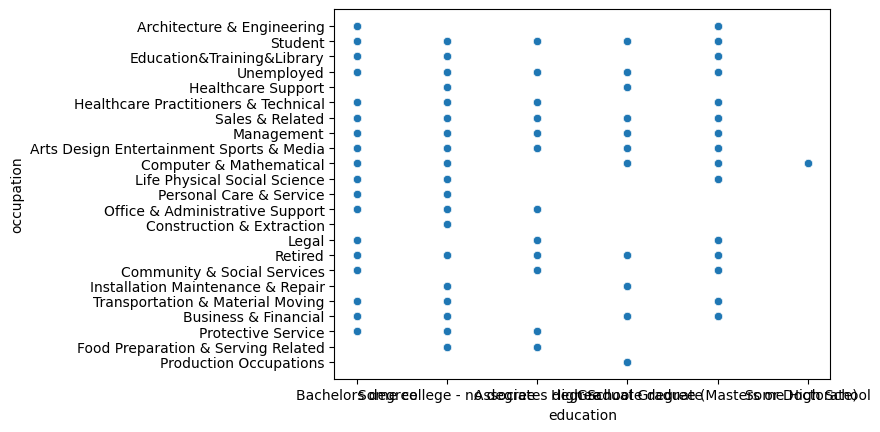

In [37]:
sns.scatterplot(x="education",y="occupation",data=da)